In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv('waterQuality1.csv')
df.shape

(7999, 21)

In [37]:
df.dtypes

aluminium      float64
ammonia            str
arsenic        float64
barium         float64
cadmium        float64
chloramine     float64
chromium       float64
copper         float64
flouride       float64
bacteria       float64
viruses        float64
lead           float64
nitrates       float64
nitrites       float64
mercury        float64
perchlorate    float64
radium         float64
selenium       float64
silver         float64
uranium        float64
is_safe            str
dtype: object

In [38]:
df.ammonia = pd.to_numeric(df['ammonia'], errors='coerce')
print('broken ammonia values:', df['ammonia'].isna().sum())
df.dropna(subset=['ammonia'], inplace=True)

broken ammonia values: 3


In [42]:
df.is_safe = df.is_safe.astype(int)

df.rename(columns={'is_safe': 'target'}, inplace=True)

<Axes: xlabel='target', ylabel='count'>

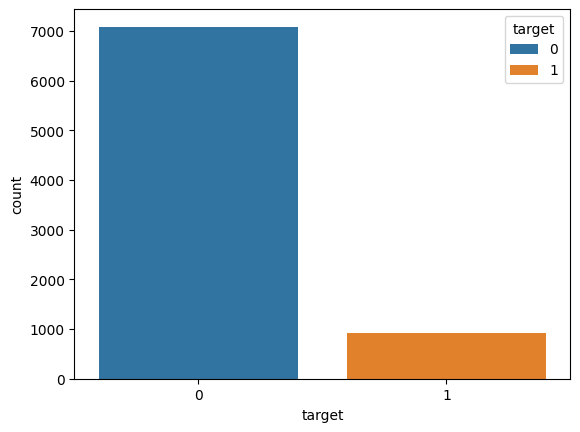

In [43]:
sns.countplot(data=df, x='target', hue='target')

In [44]:
target_corr = df.select_dtypes(include='number').corr()['target']
target_corr

aluminium      0.333974
ammonia       -0.022919
arsenic       -0.123362
barium         0.090858
cadmium       -0.256034
chloramine     0.186704
chromium       0.182306
copper         0.029498
flouride       0.006550
bacteria      -0.022077
viruses       -0.097040
lead          -0.009970
nitrates      -0.072100
nitrites       0.046986
mercury       -0.036817
perchlorate    0.075735
radium         0.064743
selenium      -0.030923
silver         0.102813
uranium       -0.075619
target         1.000000
Name: target, dtype: float64

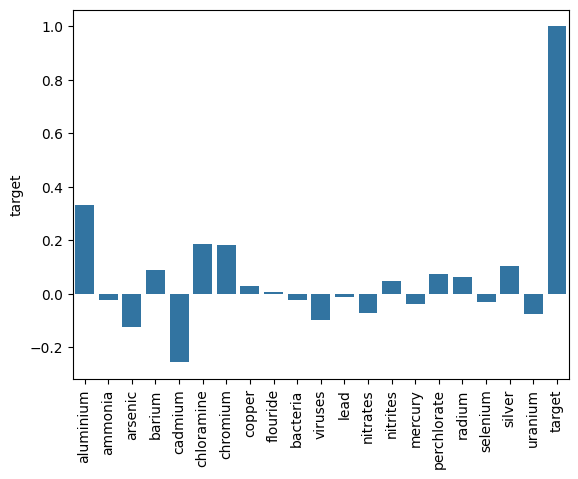

In [45]:
sns.barplot(target_corr)
plt.xticks(rotation=90)
plt.show()

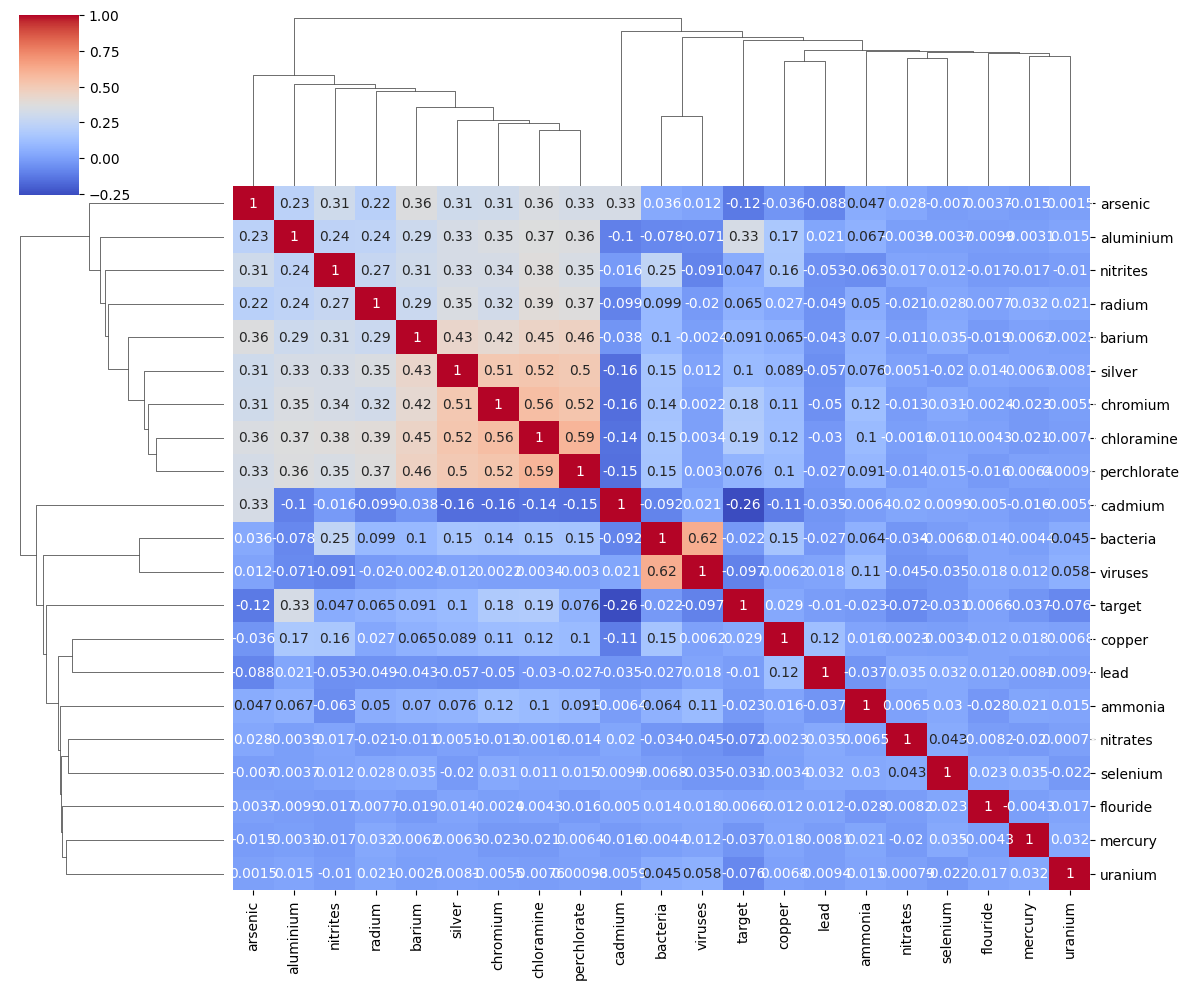

In [46]:
sns.clustermap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', figsize=(12, 10))

In [50]:
df.to_csv('waterQuality_cleaned.csv', index=False)